# Assignment 1 Part 2

## Part 2a

* Predicting house prices where the relationship between income and house price appears approximately linear
- Linear
- Since the relationship is described as approximately linear, a straight line fit captures the data well. 
* Predicting house prices where house prices increase rapidly for low incomes but level off for high incomes
- Non-linear
- This describe a logarithmic shape which a straight line can't represent, a linear model would either underfit the steep initial rise of the plateau.
* Predicting whether a wine belongs to one of three wine types when straight decision boundaries can separate the classes
- Linear
- Since the classes can already be separated by straight lines, a linear classifier can solve this without needing curved boundaries.
* Predicting whether a student passes an exam where the probability of passing depends strongly on an interaction between study hours and sleep hours
- Non-linear
- There's an interaction effect where study hours depends on the amount of sleep, so the two features interact rather than acting independently. So, a basic linear model can't capture this.
* Predicting the value of y from x, where the relationship follows approximately y = x^2
- Non-linear
- It's a quadratic relationship, a straight line cannot fit a curve that rises at changing the way x^2 does.

## Part 2b

* y = 3x + 5
- Linear
- x is a first power and multiplied by a constant.
* y = x^2 + 2
- Non-linear
- x is squared, which creates a curved relationship between x and y.
* y = log(x)
- Non-linear
- x is inside a logarithmic function, which is not a linear function.
* y = 4x1 − 2x2 + 7
- Linear
- x1 and x2 is a first power.
* y = sin(x)
- Non-linear
- x is inside a sin function, which creates a curve and periodic relationship.

## Part 2c

### Housing Dataset

In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing

# as_frame=True returns the 8 features and the target already joined in one DataFrame.
housing = fetch_california_housing(as_frame=True)
housing_df = housing.frame

print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib:
https://lib.stat.cmu.edu/datasets/houses.zip

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per census
block group. A block g

In [143]:
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


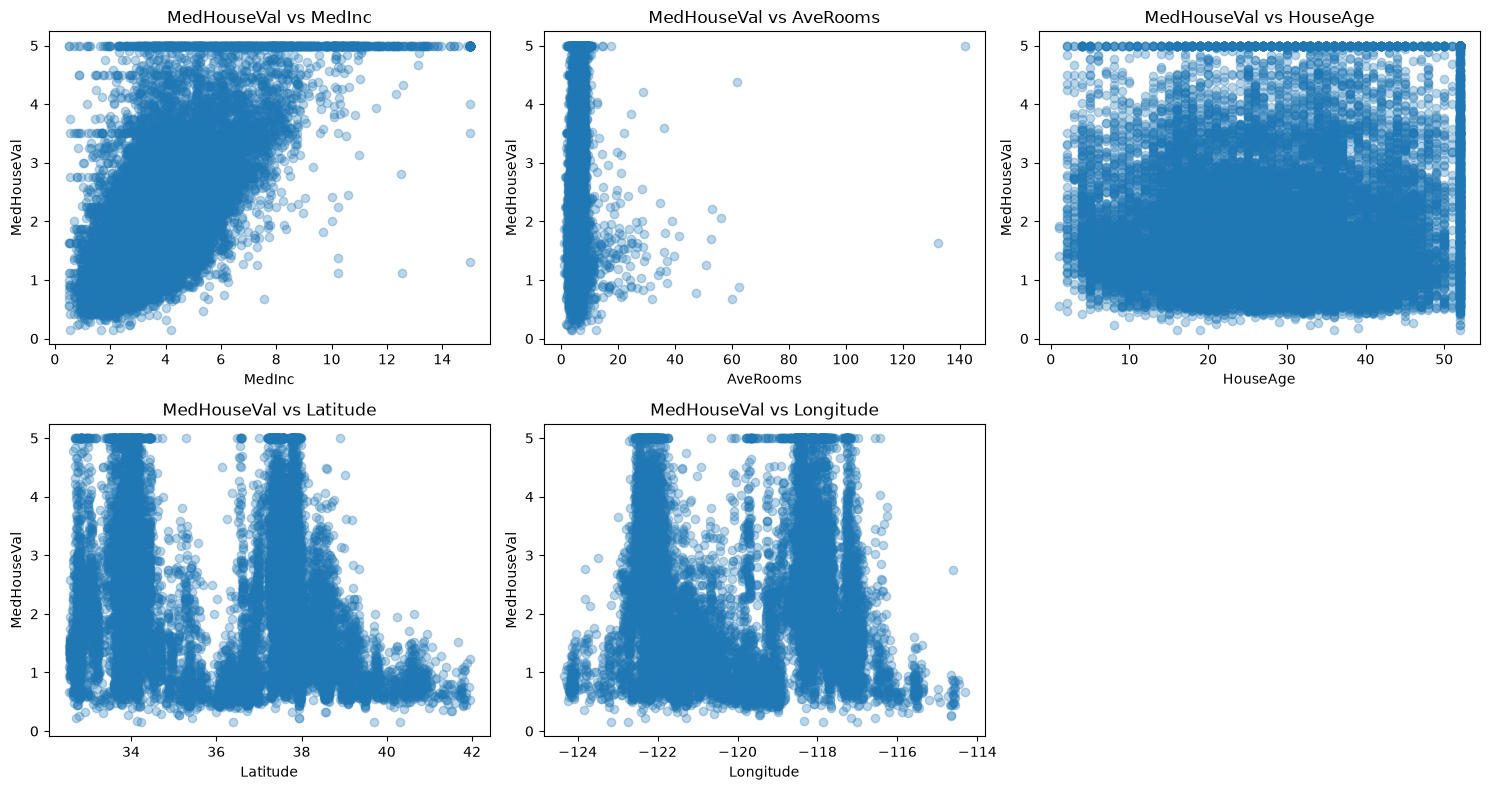

In [144]:
# Selected features
features = ['MedInc', 'AveRooms', 'HouseAge', 'Latitude', 'Longitude']

# Scatter plots for each selected feature against the target variable 'MedHouseVal'
f, axes = plt.subplots(2, 3, figsize = (15, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].scatter(x = housing_df[features[i]], y = housing_df['MedHouseVal'], alpha = 0.3)
    axes[i].set_ylabel('MedHouseVal')
    axes[i].set_xlabel(features[i])
    axes[i].set_title(f'MedHouseVal vs {features[i]}')

f.delaxes(axes[5])

plt.tight_layout()
plt.show()

In [145]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Decision Tree Regressor with selected features

x_selected = housing_df[features]
y = housing_df['MedHouseVal']

x_train, x_test, y_train, y_test = train_test_split(x_selected, y, test_size = 0.2, random_state = 42)

dectree_selected = DecisionTreeRegressor(random_state = 42)
dectree_selected.fit(x_train, y_train)
train_selected = dectree_selected.predict(x_train)
pred_selected = dectree_selected.predict(x_test)

print("Selected Features (Train):")
print("MSE:",mean_squared_error(y_train, train_selected))
print("R²", r2_score(y_train, train_selected), "\n")

print("Selected features (Test):")
print("MSE:", mean_squared_error(y_test, pred_selected))
print("R²:", r2_score(y_test, pred_selected))

Selected Features (Train):
MSE: 6.588173378753484e-32
R² 1.0 

Selected features (Test):
MSE: 0.47278511489750485
R²: 0.63920797037565


In [146]:
dectree_selected_pruned = DecisionTreeRegressor(random_state = 42, max_depth=11)
dectree_selected_pruned.fit(x_train, y_train)
train_selected = dectree_selected_pruned.predict(x_train)
pred_selected = dectree_selected_pruned.predict(x_test)

print("Selected Features (Train):")
print("MSE:",mean_squared_error(y_train, train_selected))
print("R²", r2_score(y_train, train_selected), "\n")

print("Selected features (Test):")
print("MSE:", mean_squared_error(y_test, pred_selected))
print("R²:", r2_score(y_test, pred_selected))

Selected Features (Train):
MSE: 0.17979759002995938
R² 0.8654993113709715 

Selected features (Test):
MSE: 0.40727169824213555
R²: 0.6892026039161763


In [147]:
# Decision Tree Regressor with all features 

x = housing_df[housing.feature_names]

x_train_all, x_test_all, y_train_all, y_test_all = train_test_split(x, y, test_size = 0.2, random_state = 42)

dectree_all = DecisionTreeRegressor(random_state = 42, max_depth=11)
dectree_all.fit(x_train_all, y_train_all)
train_all = dectree_all.predict(x_train_all)
pred_all = dectree_all.predict(x_test_all)

print("All Features (Train):")
print("MSE:",mean_squared_error(y_train_all, train_all))
print("R²", r2_score(y_train_all, train_all), "\n")

print("All features (Test):")
print("MSE:", mean_squared_error(y_test_all, pred_all))
print("R²:", r2_score(y_test_all, pred_all))

All Features (Train):
MSE: 0.17301248491716176
R² 0.8705750262898396 

All features (Test):
MSE: 0.4242250952059461
R²: 0.6762651185621238


|   | MSE | test $R^2$ | train $R^2$ |
|:--|:---:|:----------:|:----------:|
|selected (5)| 0.4073 | 0.6892 | 0.8655 |
| all (8) | 0.4242 | 0.6763 | 0.8706 |
| linear regression | 0.6434 | 0.5438| 0.5089 |


The selected features model (MedInc, AveRooms, HouseAge, Latitude, Longitude) produced a lower MSE (0.4073 vs 0.4242) and a higher R2 (0.6892 vs 0.6763) than compared to the models with all 8 features, at equal depth of 11. 

Selected features model finetuned to depth 11 which produced the best results. With no depth limit, the model was overfitted to the training data.

This suggests that the excluded features (AveBedrms, Population, and AveOccup) contributed mostly noise rather than useful signal, and that the nonlinear relationship visible in the Latitude and Longitude scatter plots was well captured by the decision tree using the selected features alone. 

Comparing the results to the linear regression model, we can see that the non-linear decision tree has a better performance. This could mean that the features have a non-linear relationship to the target.

In [ ]:
# Checking for negative values in Latitude and Longitude
# Checking to make sure that the log transformation will be viable

print(housing_df['Latitude'].min(), housing_df['Latitude'].max())
print(housing_df['Longitude'].min(), housing_df['Longitude'].max())

32.54 41.95
-124.35 -114.31


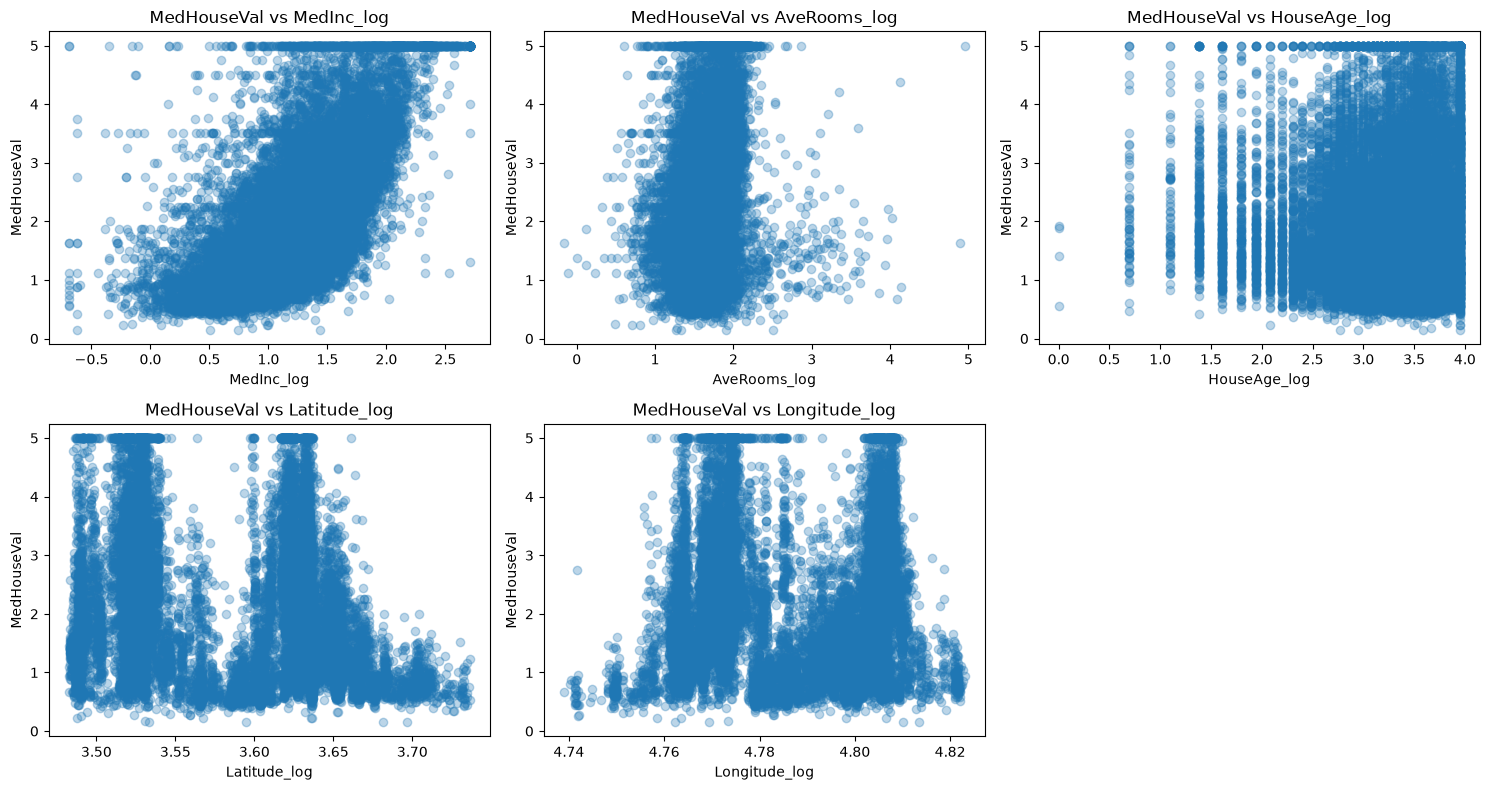

In [149]:
# Log transformation of features

transformed_features_log = {}

for feature in features:
    if feature == 'Longitude':
        transformed_features_log[f'{feature}_log'] = np.log(np.abs(housing_df[feature]))
    else:
        transformed_features_log[f'{feature}_log'] = np.log(housing_df[feature])

f, axes = plt.subplots(2, 3, figsize = (15, 8))
axes = axes.flatten()

for i, (feature, values) in enumerate(transformed_features_log.items()):
    axes[i].scatter(values, housing_df['MedHouseVal'], alpha = 0.3)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('MedHouseVal')
    axes[i].set_title(f'MedHouseVal vs {feature}')

f.delaxes(axes[5])

plt.tight_layout()
plt.show()

In [150]:
x_selected_trans = pd.DataFrame(transformed_features_log)
y_trans = housing_df['MedHouseVal']

x_train_trans, x_test_trans, y_train_trans, y_test_trans = train_test_split(x_selected_trans, y_trans, test_size = 0.2, random_state = 42)

dectree_selected_trans = DecisionTreeRegressor(random_state = 42, max_depth=11)
dectree_selected_trans.fit(x_train_trans, y_train_trans)
train_selected_trans = dectree_selected_trans.predict(x_train_trans)
pred_selected_trans = dectree_selected_trans.predict(x_test_trans)

print("Selected Features Transformed (Train):")
print("MSE:",mean_squared_error(y_train_trans, train_selected_trans))
print("R²", r2_score(y_train_trans, train_selected_trans), "\n")

print("Selected features Transformed (Test):")
print("MSE:", mean_squared_error(y_test_trans, pred_selected_trans))
print("R²:", r2_score(y_test_trans, pred_selected_trans))

Selected Features Transformed (Train):
MSE: 0.1797975900299594
R² 0.8654993113709714 

Selected features Transformed (Test):
MSE: 0.40793857708729914
R²: 0.6886936949753517


|   | MSE | test $R^2$ | train $R^2$ |
|:--|:---:|:----------:|:----------:|
|selected (5)| 0.4073 | 0.6892 | 0.8655 |
| transformed (5) | 0.408 | 0.6887 | 0.8655 |

After comparing the results of the same model on the transformed data, we can see that the results are negligible and could possibly be noise.

Therefore, we can conclude that the transformation was not significant.

This could be attributed to how a Decision Tree works. As decision trees use rank order of values, and the log transformation preserves rank order, the decision thresholds will create similar partitions.

We can not conclude from this if the transformed features are non-linearly related to the target.

In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

wine = load_wine(as_frame=True)
df = wine.frame

print(wine.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

In [153]:
#Features selected

selected_features = [
    'alcohol',
    'flavanoids',
    'total_phenols',
    'color_intensity',
    'proline',
    'od280/od315_of_diluted_wines'
]

X_selected = df[selected_features]
y = df['target']

In [154]:
#Split into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42
)

In [155]:
#Building the nonlinear SVM

svm_selected = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf')
)

In [156]:
#Train model

svm_selected.fit(X_train, y_train)
y_train_pred = svm_selected.predict(X_train)
y_test_pred = svm_selected.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Training accuracy:", train_accuracy)
print("Test accuracy:", test_accuracy)

Training accuracy: 0.9859154929577465
Test accuracy: 1.0


In [158]:
#Compare with All Features

X_all = df[wine.feature_names]

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all,
    y,
    test_size=0.2,
    random_state=42
)

svm_all = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf')
)

svm_all.fit(X_train_all, y_train_all)

y_train_pred_all = svm_all.predict(X_train_all)
y_test_pred_all = svm_all.predict(X_test_all)

train_accuracy_all = accuracy_score(y_train_all, y_train_pred_all)
test_accuracy_all = accuracy_score(y_test_all, y_test_pred_all)

print("Training accuracy - All features:", train_accuracy_all)
print("Test accuracy - All features:", test_accuracy_all)

Training accuracy - All features: 1.0
Test accuracy - All features: 1.0


|   | Train Accuracy | Test Accuracy |
|:--|:-------------:|:--------------:|
|selected (6)| 0.9859 | 1.0 |
| all (13) | 1.0 | 1.0 |
| Logistic Regression | 0.9789 | 1.0 |

From the training and test set we can say that this classes separable with a nonlinear boundary.

Comparing training and testing results, the all features result suggests that using additional features did not improve test accuracy. This suggests the six selected features already contain enough information to distinguish the wine classes very well.

However, this does not immediately justify that using Support Vector Machine (SVM) the best method to use to decide boundaries. The nonlinear SVM successfully separated the three wine classes, achieving 100% test accuracy. 

However, the linear logistic regression used in Part Ic also achieved 100% test accuracy. Therefore, although a nonlinear model can separate the classes effectively, results show that a linear boundary will do. The selected features already appear to provide strong separation between the classes.

In [160]:
#Feature Transformation

X_selected_log = np.log1p(X_selected)
X_selected_log.head()

,alcohol,flavanoids,total_phenols,color_intensity,proline,od280/od315_of_diluted_wines
0,2.723267,1.401183,1.335001,1.893112,6.971669,1.593309
1,2.653242,1.324419,1.294727,1.682688,6.957497,1.481605
2,2.650421,1.444563,1.335001,1.899118,7.078342,1.427916
3,2.732418,1.501853,1.578979,2.174752,7.300473,1.492904
4,2.656055,1.305626,1.335001,1.671473,6.601230,1.368639


In [161]:
#Train SVM using Transformed Features

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_selected_log,
    y,
    test_size=0.2,
    random_state=42
)

svm_log = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf')
)

svm_log.fit(X_train_log, y_train_log)

y_train_pred_log = svm_log.predict(X_train_log)
y_test_pred_log = svm_log.predict(X_test_log)

train_accuracy_log = accuracy_score(y_train_log, y_train_pred_log)
test_accuracy_log = accuracy_score(y_test_log, y_test_pred_log)

print("Training accuracy - Log transformed:", train_accuracy_log)
print("Test accuracy - Log transformed:", test_accuracy_log)

Training accuracy - Log transformed: 0.9859154929577465
Test accuracy - Log transformed: 1.0


The SVM again achieved approximately 98.6% training accuracy and 100% test accuracy after the logarithmic transformation. This shows that the untransformed features are sufficient to separate the classes effectively. 